 In order to first evaluate the bhdsgan I will use the following procedure:
 1. Sample from a truncated normal distribution with high variance --> gan should perform poorly
 2. Train gan on sampled data
 3. Generate new data and estimate density
 4. Compare actual and estimated density
 5. Sample from a truncated normal distribution with low variance --> gan should perform quite well
 6.Train gan on sampled data
 7. Generate new data and estimate density
 8. Compare actual and estimated density

In [1]:
%load_ext autoreload
%autoreload 2

In [54]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
from torch import nn
from bhsgan import DiscriminatorBhsSim, GeneratorBhsSim,GeneratorBhsSimNormal
from dataset import SampleDataset
from ipmbhsgan import DiscriminatorIpmSim, GeneratorIpmSim
from trainer import (Trainer, TrainingParams, get_dis_loss_bhs,
                     get_dis_loss_ipm, get_dis_loss_wasserstein,
                     get_gen_loss_bhs, get_gen_loss_ipm,
                     get_gen_loss_wasserstein,get_dis_loss_kl, get_gen_loss_kl, get_dis_loss_rkl, get_gen_loss_rkl,
                     get_dis_loss_gan, get_gen_loss_gan, get_dis_loss_p, get_gen_loss_p)
from utils import get_device, get_noise, init_weights, plot_tensor_images, plot_losses, BhsActivation, save_models_state_dict, load_model_state_dict, RevKlActivation, GanGanActivation
from wgan import DiscriminatorWassersteinSim, GeneratorWassersteinSim, GeneratorWassersteinSimNormal
import random
from scipy.stats import lognorm

torch.set_default_dtype(torch.float64)
torch.manual_seed(96)
random.seed(96)

## sample from beta distribution

In [3]:
# sample from beta distributions
mean_1_low = 0
sd_1_low = 0.5
mean_2_low = 5
sd_2_low = 1
mean_1_high = 0
sd_1_high = 2
mean_2_high = 5
sd_2_high = 2


In [7]:
# beta_sample_high = np.random.beta(a_high, b_high, 10000)
normal_sample_1_high = np.random.choice(np.random.lognormal(mean_1_high, sd_1_high, 10000), 5000)
normal_sample_2_high = np.random.choice(np.random.lognormal(mean_2_high, sd_2_high, 10000), 5000)
sample_high = np.concatenate([normal_sample_1_high, normal_sample_2_high])
beta_sample_high = np.reshape(sample_high, (5000, 2))

In [ ]:
sns.set_style('whitegrid')
sns.histplot(beta_sample_high)

<AxesSubplot:ylabel='Count'>

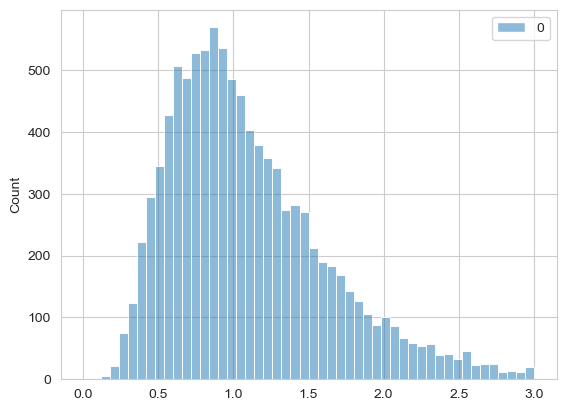

In [4]:
normal_sample_1_low = np.random.lognormal(mean_1_low, sd_1_low, 10000)
#normal_sample_2_low = np.random.choice(np.random.normal(mean_2_low, sd_2_low, 10000), 5000)
#sample_low = np.concatenate([normal_sample_1_low, normal_sample_2_low])
beta_sample_low = np.reshape(normal_sample_1_low, (10000, 1))
sns.set_style('whitegrid')
sns.histplot(beta_sample_low.ravel, bins=50, binrange=[0,3])

<AxesSubplot:ylabel='Count'>

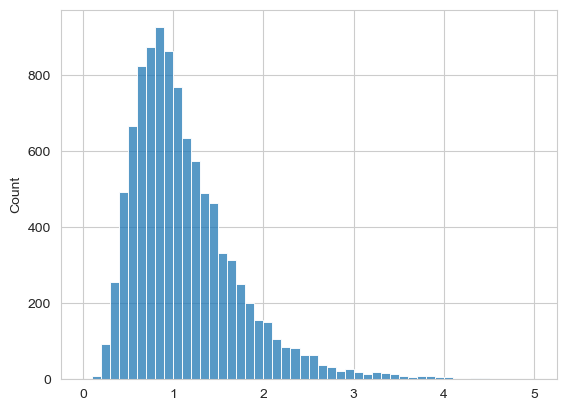

In [50]:
sns.histplot(beta_sample_low.ravel(), bins=50, binrange=[0,5])

In [5]:
beta_sample_low

array([[0.96019888],
       [1.67277428],
       [1.0539382 ],
       ...,
       [5.49355352],
       [1.44827643],
       [1.67631913]])

In [8]:
training_set_high = SampleDataset(beta_sample_high)
training_set_low = SampleDataset(beta_sample_low)

In [9]:
test_noise = get_noise(10000, 1)

## Train BHS GAN

In [10]:
# old seed 97
torch.manual_seed(121)
random.seed(121)
training_params = TrainingParams(lr_dis=0.00005,
                                 lr_gen=0.00005,
                                 num_epochs=25,
                                 num_dis_updates=2,
                                 num_gen_updates=2,
                                 beta_1=0.5,
                                 beta_2=0.999,
                                 weight_decay=0,
                                 batch_size=128, 
                                 lr_annealing=False)
 
# get device to train on
device = "cpu"

In [171]:
# Create the dataloaders
dataloader_high = torch.utils.data.DataLoader(training_set_high, batch_size=training_params.batch_size,
                                         shuffle=True, num_workers=1)
dataloader_low = torch.utils.data.DataLoader(training_set_low, batch_size=training_params.batch_size,
                                         shuffle=True, num_workers=1)

In [11]:
# Create the dataloaders
dataloader_high = torch.utils.data.DataLoader(training_set_high, batch_size=training_params.batch_size,
                                         shuffle=True, num_workers=1)
dataloader_low = torch.utils.data.DataLoader(training_set_low, batch_size=training_params.batch_size,
                                         shuffle=True, num_workers=1)
# initialize nets
final_activation = BhsActivation
generator_high = GeneratorBhsSimNormal()
discriminator_high = DiscriminatorBhsSim(final_activation)
generator_low = GeneratorBhsSimNormal()
discriminator_low = DiscriminatorBhsSim(final_activation)

In [12]:
# init Trainer
#trainer_high = Trainer(training_params, generator_high, discriminator_high)
trainer_low = Trainer(training_params, generator_low, discriminator_low)

### Train on high variance samples

In [150]:
# training loop
trained_bhs_high = trainer_high.train_gan(dataloader_high, get_dis_loss_bhs, get_gen_loss_bhs, False, print_intermediate=False)

NameError: name 'trainer_high' is not defined

In [ ]:
generated_data = trained_bhs_high.generator(test_noise)
generated_sample = torch.reshape(generated_data, (1, 20000)).detach().numpy().ravel()

In [ ]:
# plot resulting density
sns.set_style('whitegrid')
sns.histplot(generated_sample, bins=50)

### Train on low variance samples

In [13]:
# training loop
trained_bhs_low = trainer_low.train_gan(dataloader_low, get_dis_loss_bhs, get_gen_loss_bhs, True, print_intermediate=False)

Epoch 1 start training...
Epoch: 1/25 Total Steps:79och_Run_Time: 4.724346	Loss_C : 0.003554	Loss_G : -0.078066	
Total_Time : 5.074534
Loss_C : 0.003554
Loss_G : -0.078066
Loss_C_Mean : 0.012784
Loss_G_Mean : -0.063772

----------------------------------------------

Epoch 2 start training...
Epoch: 2/25 Total Steps:158ch_Run_Time: 4.589739	Loss_C : -0.005485	Loss_G : -0.107250	
Total_Time : 4.949023
Loss_C : -0.005485
Loss_G : -0.107250
Loss_C_Mean : 0.000971
Loss_G_Mean : -0.093192

----------------------------------------------

Epoch 3 start training...
Epoch: 3/25 Total Steps:237ch_Run_Time: 4.219069	Loss_C : -0.015780	Loss_G : -0.139565	
Total_Time : 4.664372
Loss_C : -0.015780
Loss_G : -0.139565
Loss_C_Mean : -0.012363
Loss_G_Mean : -0.122863

----------------------------------------------

Epoch 4 start training...
Epoch: 4/25 Total Steps:316ch_Run_Time: 4.744010	Loss_C : -0.034746	Loss_G : -0.167606	
Total_Time : 5.098497
Loss_C : -0.034746
Loss_G : -0.167606
Loss_C_Mean : -0.

In [14]:
generated_data_low = trained_bhs_low.generator(test_noise).detach().numpy()
generated_data_low

array([[0.86201653],
       [1.1996251 ],
       [1.05612717],
       ...,
       [0.52197505],
       [1.90111861],
       [0.53412831]])

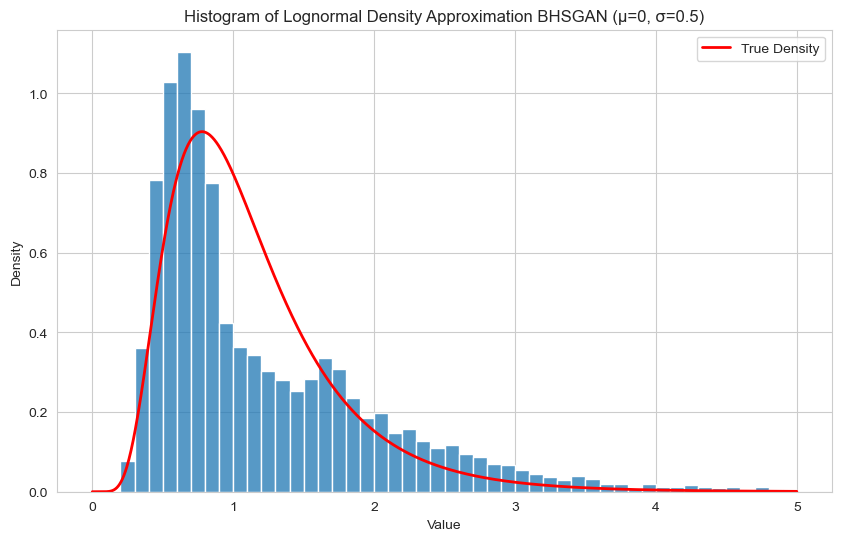

In [68]:
plt.figure(figsize=(10, 6))

# Plot histogram
sns.histplot(generated_data_low.ravel(), kde=False, stat='density', bins=50, binrange=[0,5])

# Calculate true lognormal density
x = np.linspace(0, 5, 1000)
pdf = lognorm.pdf(x, s=0.5, scale=np.exp(0))

# Plot true density
plt.plot(x, pdf, 'r-', lw=2, label='True Density')

plt.title('Histogram of Lognormal Density Approximation BHSGAN (μ=0, σ=0.5)')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()

plt.show()

<AxesSubplot:ylabel='Density'>

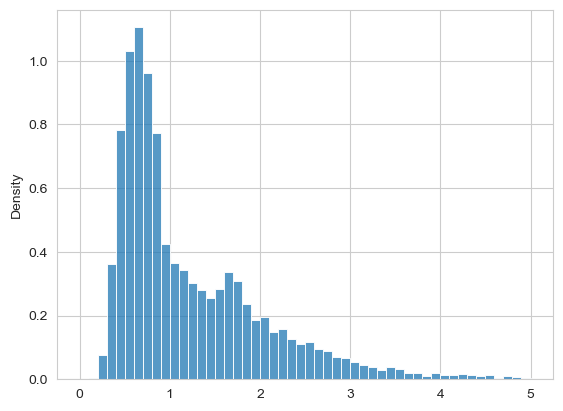

In [51]:
# plot resulting density
sns.set_style('whitegrid')
sns.histplot(generated_data_low.ravel(), bins=50, binrange=[0,5], stat="density")

## Wasserstein GAN 

### High Variance

In [ ]:
dataloader_wasserstein_high = torch.utils.data.DataLoader(training_set_high, batch_size=training_params.batch_size,
                                         shuffle=True, num_workers=1)
generator_wasserstein_high = GeneratorWassersteinSimNormal()
discriminator_wasserstein_high = DiscriminatorWassersteinSim()
trainer_wgan_high = Trainer(training_params, generator_wasserstein_high, discriminator_wasserstein_high)

In [ ]:
# training loop
trained_wgan_high = trainer_wgan_high.train_gan(dataloader_wasserstein_high, get_dis_loss_wasserstein, get_gen_loss_wasserstein, True, print_intermediate=False)

In [ ]:
generated_data_wasserstein_high = trained_wgan_high.generator(test_noise)
generated_sample_wasserstein_high = torch.reshape(generated_data_wasserstein_high, (1, 20000)).detach().numpy().ravel()
# plot resulting density
sns.set_style('whitegrid')
sns.histplot(generated_sample_wasserstein_high, bins=100)

### Low Variance

In [16]:
dataloader_wasserstein_low = torch.utils.data.DataLoader(training_set_low, batch_size=training_params.batch_size,
                                         shuffle=True, num_workers=1)
generator_wasserstein_low = GeneratorWassersteinSimNormal()
discriminator_wasserstein_low = DiscriminatorWassersteinSim()
trainer_wgan_low = Trainer(training_params, generator_wasserstein_low, discriminator_wasserstein_low)

In [17]:
# training loop
trained_wgan_low = trainer_wgan_low.train_gan(dataloader_wasserstein_low, get_dis_loss_wasserstein, get_gen_loss_wasserstein, True, print_intermediate=False)

Epoch 1 start training...
Epoch: 1/25 Total Steps:79och_Run_Time: 5.100347	Loss_C : 0.001028	Loss_G : -0.292549		
Total_Time : 5.529458
Loss_C : 0.001028
Loss_G : -0.292549
Loss_C_Mean : -0.060299
Loss_G_Mean : -0.260708

----------------------------------------------

Epoch 2 start training...
Epoch: 2/25 Total Steps:158ch_Run_Time: 4.187404	Loss_C : -0.037922	Loss_G : -0.364623	
Total_Time : 4.545641
Loss_C : -0.037922
Loss_G : -0.364623
Loss_C_Mean : -0.065643
Loss_G_Mean : -0.318253

----------------------------------------------

Epoch 3 start training...
Epoch: 3/25 Total Steps:237ch_Run_Time: 4.771720	Loss_C : -0.153747	Loss_G : -0.393367	
Total_Time : 5.112478
Loss_C : -0.153747
Loss_G : -0.393367
Loss_C_Mean : -0.066750
Loss_G_Mean : -0.375742

----------------------------------------------

Epoch 4 start training...
Epoch: 4/25 Total Steps:316ch_Run_Time: 5.195082	Loss_C : -0.016220	Loss_G : -0.470179	
Total_Time : 5.571399
Loss_C : -0.016220
Loss_G : -0.470179
Loss_C_Mean : 

<AxesSubplot:ylabel='Count'>

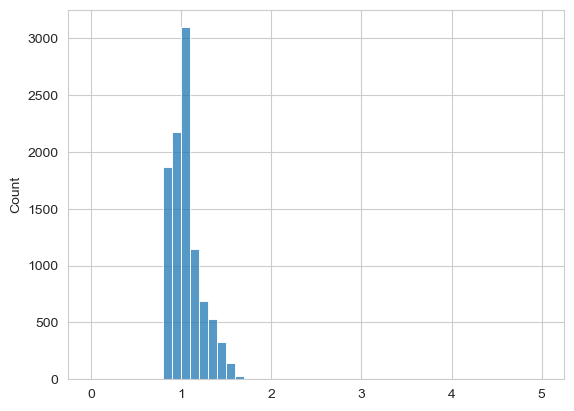

In [47]:
generated_data_wasserstein_low = trained_wgan_low.generator(test_noise)
generated_sample_wasserstein_low = generated_data_wasserstein_low.detach().numpy().ravel()
# plot resulting density
sns.set_style('whitegrid')
sns.histplot(generated_sample_wasserstein_low, bins=50, binrange=[0,5])

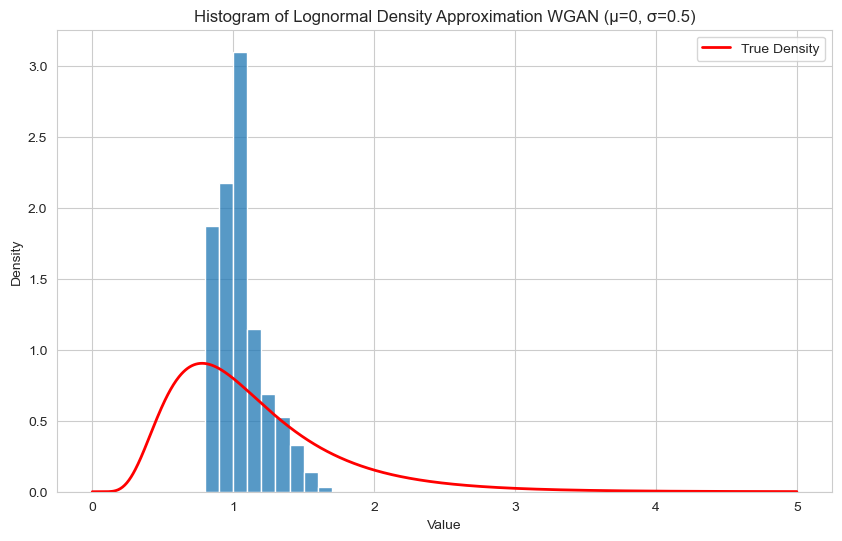

In [69]:
plt.figure(figsize=(10, 6))

# Plot histogram
sns.histplot(generated_sample_wasserstein_low, kde=False, stat='density', bins=50, binrange=[0,5])

# Calculate true lognormal density
x = np.linspace(0, 5, 1000)
pdf = lognorm.pdf(x, s=0.5, scale=np.exp(0))

# Plot true density
plt.plot(x, pdf, 'r-', lw=2, label='True Density')

plt.title('Histogram of Lognormal Density Approximation WGAN (μ=0, σ=0.5)')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()

plt.show()

## GAN GAN 

In [19]:
# Create the dataloaders
dataloader_high = torch.utils.data.DataLoader(training_set_high, batch_size=training_params.batch_size,
                                         shuffle=True, num_workers=1)
dataloader_low = torch.utils.data.DataLoader(training_set_low, batch_size=training_params.batch_size,
                                         shuffle=True, num_workers=1)
# initialize nets
final_activation = nn.Sigmoid
generator_gan_high = GeneratorBhsSimNormal()
discriminator_gan_high = DiscriminatorBhsSim(final_activation)
generator_gan_low = GeneratorBhsSimNormal()
discriminator_gan_low = DiscriminatorBhsSim(final_activation)

In [ ]:
### High Variance

In [ ]:
trainer_gan_high = Trainer(training_params, generator_gan_high, discriminator_gan_high)

In [ ]:
# training loop
trained_gan_high = trainer_gan_high.train_gan(dataloader_high, get_dis_loss_gan, get_gen_loss_gan, False, print_intermediate=False)

In [ ]:
generated_data_gan_high = trained_gan_high.generator(test_noise)
generated_sample_gan_high = torch.reshape(generated_data_gan_high, (1, 20000)).detach().numpy().ravel()
# plot resulting density
sns.set_style('whitegrid')
sns.histplot(generated_sample_gan_high, bins=50)

In [ ]:
### Low Variance

In [20]:
trainer_gan_low = Trainer(training_params, generator_gan_low, discriminator_gan_low)

In [21]:
# training loop
trained_gan_low = trainer_gan_low.train_gan(dataloader_low, get_dis_loss_gan, get_gen_loss_gan, False, print_intermediate=False)

Epoch 1 start training...
Epoch: 1/25 Total Steps:79och_Run_Time: 3.958193	Loss_C : 1.458690	Loss_G : 0.498905	
Total_Time : 4.287190
Loss_C : 1.458690
Loss_G : 0.498905
Loss_C_Mean : 1.468776
Loss_G_Mean : 0.488780

----------------------------------------------

Epoch 2 start training...
Epoch: 2/25 Total Steps:158ch_Run_Time: 3.958918	Loss_C : 1.410813	Loss_G : 0.525041	
Total_Time : 4.296906
Loss_C : 1.410813
Loss_G : 0.525041
Loss_C_Mean : 1.465924
Loss_G_Mean : 0.502330

----------------------------------------------

Epoch 3 start training...
Epoch: 3/25 Total Steps:237ch_Run_Time: 3.911236	Loss_C : 1.537614	Loss_G : 0.495278	
Total_Time : 4.259309
Loss_C : 1.537614
Loss_G : 0.495278
Loss_C_Mean : 1.463898
Loss_G_Mean : 0.515909

----------------------------------------------

Epoch 4 start training...
Epoch: 4/25 Total Steps:316ch_Run_Time: 3.955866	Loss_C : 1.425992	Loss_G : 0.549753	
Total_Time : 4.384638
Loss_C : 1.425992
Loss_G : 0.549753
Loss_C_Mean : 1.459880
Loss_G_Mean 

<AxesSubplot:ylabel='Count'>

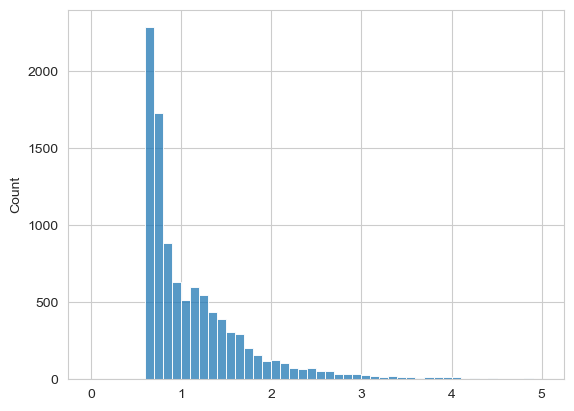

In [46]:
generated_data_gan_low = trained_gan_low.generator(test_noise)
generated_sample_gan_low = generated_data_gan_low.detach().numpy().ravel()
# plot resulting density
sns.set_style('whitegrid')
sns.histplot(generated_sample_gan_low, bins=50, binrange=[0,5])

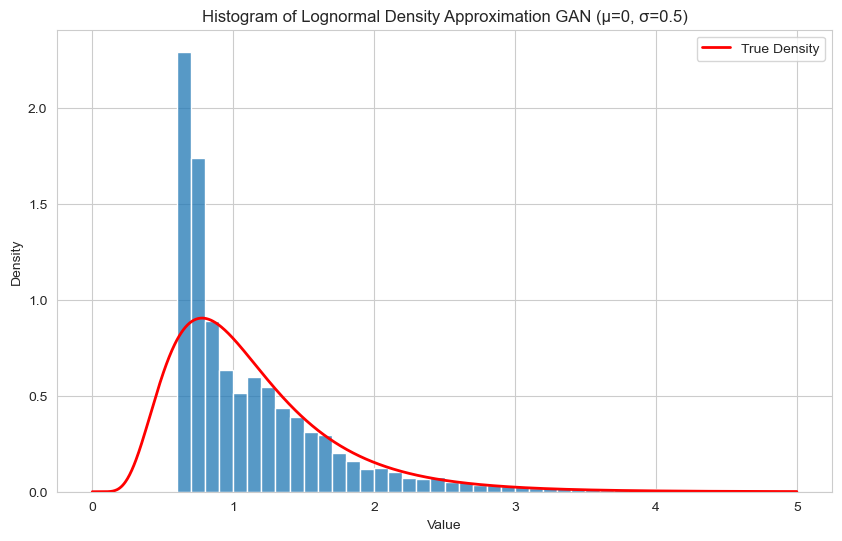

In [70]:
plt.figure(figsize=(10, 6))

# Plot histogram
sns.histplot(generated_sample_gan_low, kde=False, stat='density', bins=50, binrange=[0,5])

# Calculate true lognormal density
x = np.linspace(0, 5, 1000)
pdf = lognorm.pdf(x, s=0.5, scale=np.exp(0))

# Plot true density
plt.plot(x, pdf, 'r-', lw=2, label='True Density')

plt.title('Histogram of Lognormal Density Approximation GAN (μ=0, σ=0.5)')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()

plt.show()

## Pearson GAN

In [23]:
# Create the dataloaders
dataloader_high = torch.utils.data.DataLoader(training_set_high, batch_size=training_params.batch_size,
                                         shuffle=True, num_workers=1)
dataloader_low = torch.utils.data.DataLoader(training_set_low, batch_size=training_params.batch_size,
                                         shuffle=True, num_workers=1)
# initialize nets
final_activation = nn.Identity
generator_pearson_high = GeneratorBhsSimNormal()
discriminator_pearson_high = DiscriminatorBhsSim(final_activation)
generator_pearson_low = GeneratorBhsSimNormal()
discriminator_pearson_low = DiscriminatorBhsSim(final_activation)

In [ ]:
### High Variance

In [ ]:
trainer_pearson_high = Trainer(training_params, generator_pearson_high, discriminator_pearson_high)

In [24]:
# training loop
trained_pearson_high = trainer_pearson_high.train_gan(dataloader_high, get_dis_loss_p, get_gen_loss_p, False, print_intermediate=False)

NameError: name 'trainer_pearson_high' is not defined

In [ ]:
generated_data_pearson_high = trained_pearson_high.generator(test_noise)
generated_sample_pearson_high = torch.reshape(generated_data_pearson_high, (1, 20000)).detach().numpy().ravel()
# plot resulting density
sns.set_style('whitegrid')
sns.histplot(generated_sample_pearson_high, bins=50)

In [ ]:
### Low Variance

In [26]:
trainer_pearson_low = Trainer(training_params, generator_pearson_low, discriminator_pearson_low)

In [28]:
# training loop
trained_pearson_low = trainer_pearson_low.train_gan(dataloader_low, get_dis_loss_p, get_gen_loss_p, True, print_intermediate=False)

Epoch 1 start training...
Epoch: 1/25 Total Steps:79och_Run_Time: 4.728354	Loss_C : 0.026693	Loss_G : 0.494030	
Total_Time : 5.147352
Loss_C : 0.026693
Loss_G : 0.494030
Loss_C_Mean : 0.050528
Loss_G_Mean : 0.533872

----------------------------------------------

Epoch 2 start training...
Epoch: 2/25 Total Steps:158ch_Run_Time: 4.473016	Loss_C : -0.021405	Loss_G : 0.457321	
Total_Time : 4.834390
Loss_C : -0.021405
Loss_G : 0.457321
Loss_C_Mean : 0.040819
Loss_G_Mean : 0.487811

----------------------------------------------

Epoch 3 start training...
Epoch: 3/25 Total Steps:237ch_Run_Time: 4.040134	Loss_C : 0.083889	Loss_G : 0.421518	
Total_Time : 4.443761
Loss_C : 0.083889
Loss_G : 0.421518
Loss_C_Mean : 0.031022
Loss_G_Mean : 0.443929

----------------------------------------------

Epoch 4 start training...
Epoch: 4/25 Total Steps:316ch_Run_Time: 4.493797	Loss_C : 0.008718	Loss_G : 0.369924		
Total_Time : 4.859791
Loss_C : 0.008718
Loss_G : 0.369924
Loss_C_Mean : 0.021170
Loss_G_Me

<AxesSubplot:ylabel='Count'>

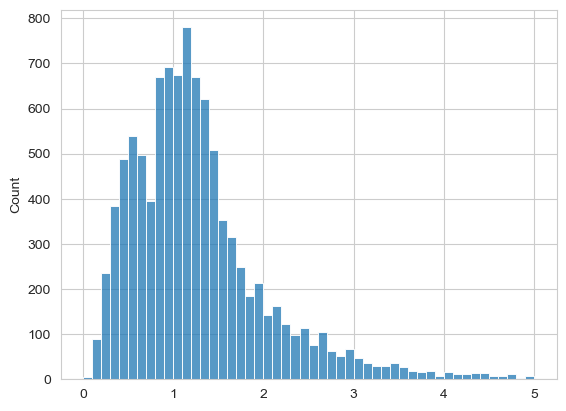

In [45]:
generated_data_pearson_low = trained_pearson_low.generator(test_noise)
generated_sample_pearson_low = generated_data_pearson_low.detach().numpy().ravel()
# plot resulting density
sns.set_style('whitegrid')
sns.histplot(generated_sample_pearson_low, bins=50, binrange=[0,5])

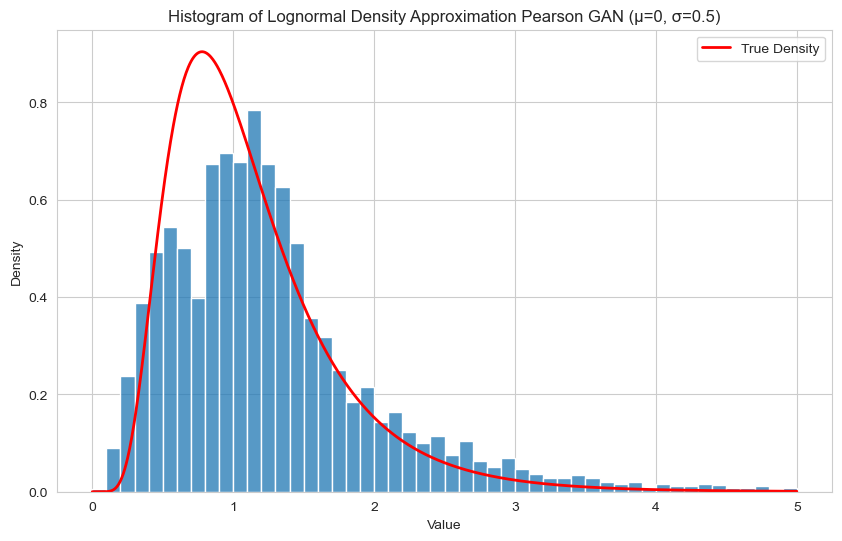

In [71]:
plt.figure(figsize=(10, 6))

# Plot histogram
sns.histplot(generated_sample_pearson_low, kde=False, stat='density', bins=50, binrange=[0,5])

# Calculate true lognormal density
x = np.linspace(0, 5, 1000)
pdf = lognorm.pdf(x, s=0.5, scale=np.exp(0))

# Plot true density
plt.plot(x, pdf, 'r-', lw=2, label='True Density')

plt.title('Histogram of Lognormal Density Approximation Pearson GAN (μ=0, σ=0.5)')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()

plt.show()

## KL GAN

In [32]:
# Create the dataloaders
dataloader_high = torch.utils.data.DataLoader(training_set_high, batch_size=training_params.batch_size,
                                         shuffle=True, num_workers=1)
dataloader_low = torch.utils.data.DataLoader(training_set_low, batch_size=training_params.batch_size,
                                         shuffle=True, num_workers=1)
# initialize nets
final_activation = nn.Identity
generator_kl_high = GeneratorBhsSimNormal()
discriminator_kl_high = DiscriminatorBhsSim(final_activation)
generator_kl_low = GeneratorBhsSimNormal()
discriminator_kl_low = DiscriminatorBhsSim(final_activation)

In [ ]:
### High Variance

In [ ]:
trainer_kl_high = Trainer(training_params, generator_kl_high, discriminator_kl_high)

In [ ]:
# training loop
trained_kl_high = trainer_kl_high.train_gan(dataloader_high, get_dis_loss_kl, get_gen_loss_kl, False, print_intermediate=False)

In [ ]:
generated_data_kl_high = trained_kl_high.generator(test_noise)
generated_sample_kl_high = torch.reshape(generated_data_kl_high, (1, 20000)).detach().numpy().ravel()
# plot resulting density
sns.set_style('whitegrid')
sns.histplot(generated_sample_kl_high, bins=50)

In [ ]:
### Low Variance

In [33]:
trainer_kl_low = Trainer(training_params, generator_kl_low, discriminator_kl_low)

In [35]:
# training loop
trained_kl_low = trainer_kl_low.train_gan(dataloader_low, get_dis_loss_kl, get_gen_loss_kl, True, print_intermediate=False)

Epoch 1 start training...
Epoch: 1/25 Total Steps:79och_Run_Time: 4.595893	Loss_C : -0.170068	Loss_G : -0.745241	
Total_Time : 4.950745
Loss_C : -0.170068
Loss_G : -0.745241
Loss_C_Mean : -0.055513
Loss_G_Mean : -0.690437

----------------------------------------------

Epoch 2 start training...
Epoch: 2/25 Total Steps:158ch_Run_Time: 4.340344	Loss_C : -0.113490	Loss_G : -0.858861	
Total_Time : 4.712716
Loss_C : -0.113490
Loss_G : -0.858861
Loss_C_Mean : -0.065784
Loss_G_Mean : -0.792497

----------------------------------------------

Epoch 3 start training...
Epoch: 3/25 Total Steps:237ch_Run_Time: 4.445333	Loss_C : -0.030458	Loss_G : -0.924090	
Total_Time : 4.876812
Loss_C : -0.030458
Loss_G : -0.924090
Loss_C_Mean : -0.061768
Loss_G_Mean : -0.900047

----------------------------------------------

Epoch 4 start training...
Epoch: 4/25 Total Steps:316ch_Run_Time: 4.374534	Loss_C : -0.042079	Loss_G : -1.035660	
Total_Time : 4.701674
Loss_C : -0.042079
Loss_G : -1.035660
Loss_C_Mean :

<AxesSubplot:ylabel='Count'>

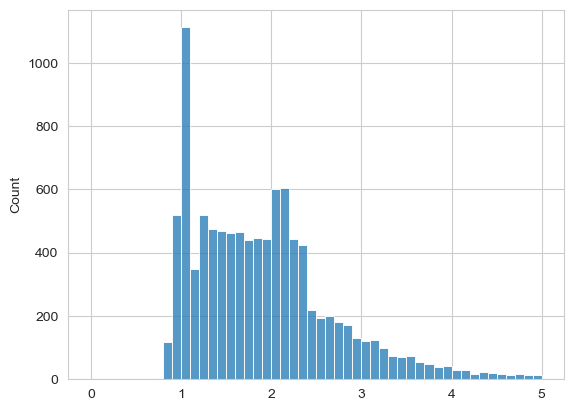

In [43]:
generated_data_kl_low = trained_kl_low.generator(test_noise)
generated_sample_kl_low = generated_data_kl_low.detach().numpy().ravel()
# plot resulting density
sns.set_style('whitegrid')
sns.histplot(generated_sample_kl_low, bins=50, binrange=[0,5])

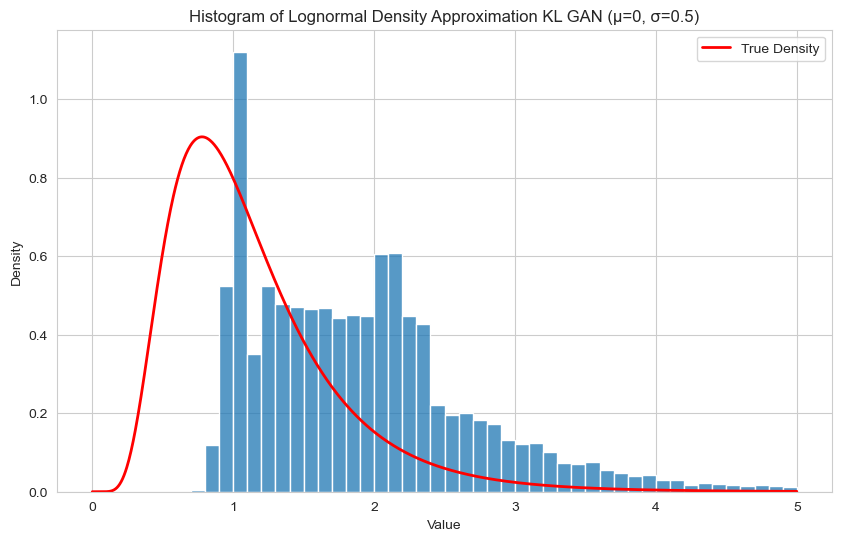

In [72]:
plt.figure(figsize=(10, 6))

# Plot histogram
sns.histplot(generated_sample_kl_low, kde=False, stat='density', bins=50, binrange=[0,5])

# Calculate true lognormal density
x = np.linspace(0, 5, 1000)
pdf = lognorm.pdf(x, s=0.5, scale=np.exp(0))

# Plot true density
plt.plot(x, pdf, 'r-', lw=2, label='True Density')

plt.title('Histogram of Lognormal Density Approximation KL GAN (μ=0, σ=0.5)')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()

plt.show()

## RV KL GAN

In [37]:
# Create the dataloaders
dataloader_high = torch.utils.data.DataLoader(training_set_high, batch_size=training_params.batch_size,
                                         shuffle=True, num_workers=1)
dataloader_low = torch.utils.data.DataLoader(training_set_low, batch_size=training_params.batch_size,
                                         shuffle=True, num_workers=1)
# initialize nets
final_activation = RevKlActivation
generator_rvkl_high = GeneratorBhsSimNormal()
discriminator_rvkl_high = DiscriminatorBhsSim(final_activation)
generator_rvkl_low = GeneratorBhsSimNormal()
discriminator_rvkl_low = DiscriminatorBhsSim(final_activation)

In [ ]:
### High Variance

In [ ]:
trainer_rvkl_high = Trainer(training_params, generator_rvkl_high, discriminator_rvkl_high)

In [ ]:
# training loop
trained_rvkl_high = trainer_rvkl_high.train_gan(dataloader_high, get_dis_loss_rkl, get_gen_loss_rkl, False, print_intermediate=False)

In [ ]:
generated_data_rvkl_high = trained_rvkl_high.generator(test_noise)
generated_sample_rvkl_high = torch.reshape(generated_data_rvkl_high, (1, 20000)).detach().numpy().ravel()
# plot resulting density
sns.set_style('whitegrid')
sns.histplot(generated_sample_rvkl_high, bins=50)

In [ ]:
### Low Variance

In [38]:
trainer_rvkl_low = Trainer(training_params, generator_rvkl_low, discriminator_rvkl_low)

In [40]:
# training loop
trained_rvkl_low = trainer_rvkl_low.train_gan(dataloader_low, get_dis_loss_rkl, get_gen_loss_rkl, True, print_intermediate=False)

Epoch 1 start training...
Epoch: 1/25 Total Steps:79och_Run_Time: 4.219504	Loss_C : -0.026110	Loss_G : 0.971114	
Total_Time : 4.565061
Loss_C : -0.026110
Loss_G : 0.971114
Loss_C_Mean : -0.011526
Loss_G_Mean : 0.922340

----------------------------------------------

Epoch 2 start training...
Epoch: 2/25 Total Steps:158ch_Run_Time: 4.467932	Loss_C : -0.050825	Loss_G : 1.043926	
Total_Time : 4.801170
Loss_C : -0.050825
Loss_G : 1.043926
Loss_C_Mean : -0.023588
Loss_G_Mean : 1.014455

----------------------------------------------

Epoch 3 start training...
Epoch: 3/25 Total Steps:237ch_Run_Time: 4.145435	Loss_C : 0.004821	Loss_G : 1.057036		
Total_Time : 4.481621
Loss_C : 0.004821
Loss_G : 1.057036
Loss_C_Mean : -0.025513
Loss_G_Mean : 1.052911

----------------------------------------------

Epoch 4 start training...
Epoch: 4/25 Total Steps:316ch_Run_Time: 4.195693	Loss_C : 0.054936	Loss_G : 1.039513		
Total_Time : 4.554398
Loss_C : 0.054936
Loss_G : 1.039513
Loss_C_Mean : -0.023045
Lo

<AxesSubplot:ylabel='Count'>

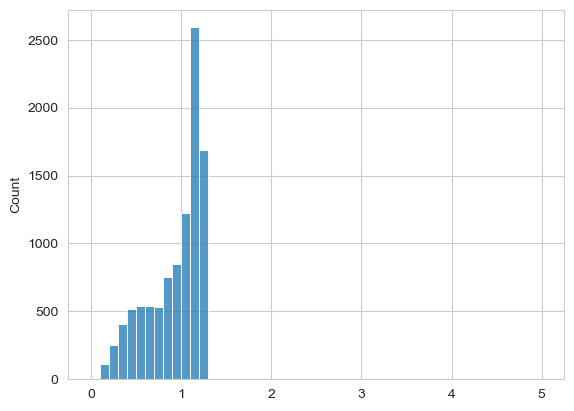

In [44]:
generated_data_rvkl_low = trained_rvkl_low.generator(test_noise)
generated_sample_rvkl_low = generated_data_rvkl_low.detach().numpy().ravel()
# plot resulting density
sns.set_style('whitegrid')
sns.histplot(generated_sample_rvkl_low, bins=50, binrange=[0,5])

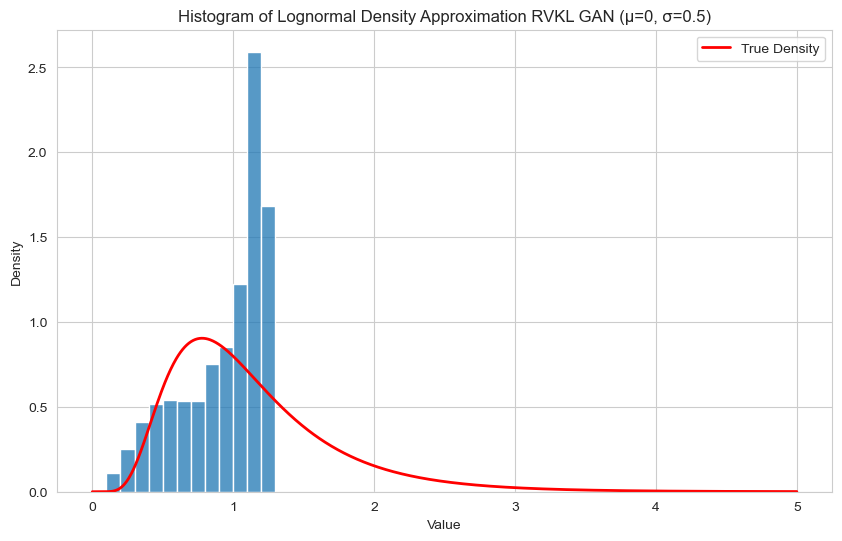

In [73]:
plt.figure(figsize=(10, 6))

# Plot histogram
sns.histplot(generated_sample_rvkl_low, kde=False, stat='density', bins=50, binrange=[0,5])

# Calculate true lognormal density
x = np.linspace(0, 5, 1000)
pdf = lognorm.pdf(x, s=0.5, scale=np.exp(0))

# Plot true density
plt.plot(x, pdf, 'r-', lw=2, label='True Density')

plt.title('Histogram of Lognormal Density Approximation RVKL GAN (μ=0, σ=0.5)')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()

plt.show()

## Now I train the IPM Version for the BHS GAN

In [ ]:
# initialize nets
generator_ipm = GeneratorIpmSim()
discriminator_ipm = DiscriminatorIpmSim()

In [ ]:
dataloader_ipm = torch.utils.data.DataLoader(training_set_low, batch_size=training_params.batch_size,
                                         shuffle=True, num_workers=1)
# init Trainer
trainer_ipm_gan = Trainer(training_params, generator_ipm, discriminator_ipm)

In [ ]:
# training loop
trained_ipm_gan = trainer_ipm_gan.train_gan(dataloader_ipm, get_dis_loss_ipm, get_gen_loss_ipm, False)

In [ ]:
generated_data_ipm = trained_ipm_gan.generator(test_noise)
generated_sample_ipm = torch.reshape(generated_data_ipm, (1, 1000)).detach().numpy().ravel()

In [ ]:
# plot resulting density
sns.set_style('whitegrid')
sns.kdeplot(generated_sample_ipm, bw=0.5)

In [ ]:
# plot losses
plt.figure(figsize=(10,5))
plt.title("Generator and Discriminator Loss During Training")
plt.plot(trained_ipm_gan.generator_losses,label="G-Loss")
plt.plot(trained_ipm_gan.discriminator_losses,label="D-Loss")
plt.xlabel("iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
# check mean and varaince of generated data
np.mean(generated_sample_ipm)

In [ ]:
np.std(generated_sample_ipm)

In [ ]:
data_points = np.linspace(-1, 2, 100)
def conjugate(points):
    conjugate_1 = 2 * (-1 + np.sqrt(1 + points)) * np.exp(-1 + np.sqrt(1 + points)) 
    conjugate_2 = 2 * (-1 - np.sqrt(1 + points)) * np.exp(-1 - np.sqrt(1 + points)) 
    return np.where(points >= 0, conjugate_1, conjugate_2)
plt.plot(data_points, conjugate(data_points))

In [ ]:
def f(points):
    f_1 = points * np.log(points)**2
    f_2 = -points * np.log(points)**2
    return np.where(points >= np.exp(-1), f_1, f_2)
plt.plot(data_points, f(data_points))

In [ ]:
2 * (-1 - np.sqrt(1 + -1)) * np.exp(-1 - np.sqrt(1 + -1))

In [ ]:
conjugate(data_points)